In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA
import multiprocessing as mp
from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier

In [2]:
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
n_clusters=500
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
# %%time
# total_path = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading total dict")
# with open(total_path, 'rb') as file:
#     total_data_dict = pickle.load(file)

# print(total_data_dict.keys())
# print(total_data_dict['250'].keys())

In [4]:
%%time
total_path = os.path.join(home_path, '10flies_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    total_data_dict = pickle.load(file)

print(total_data_dict.keys())
print(total_data_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['total', 'inc', 'dec', 'flat'])
CPU times: user 0 ns, sys: 1.64 ms, total: 1.64 ms
Wall time: 35.6 ms


In [5]:
for file in os.listdir(cluster_dir):
#     print(file)
    if f'_{n_clusters}' in file and 'labels' in file and 'total' in file:
        label_files=os.path.join(cluster_dir,file)
giant_total_labels=np.load(label_files)
print(giant_total_labels.shape)

(4171804,)


In [6]:
giant_total_labels=giant_total_labels.reshape(314,146,91)
print(giant_total_labels.shape)

(314, 146, 91)


In [7]:
#ts is in 10ms units

In [8]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
fly_num=fly_nums[-1]
dff_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/dff'
warp_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/warp'
ch_num=2
for file in os.listdir(dff_path):
    if f'_{ch_num}_' in file:
        file_path=os.path.join(dff_path,file)
for file in os.listdir(warp_path):
    if 'timestamps' in file:
        ts_path=os.path.join(warp_path,file)

In [9]:
# %%time
# cluster_brains={}
# for cluster in range(500):
#     mask=np.where(giant_total_labels==cluster,giant_total_labels,False)
#     with h5py.File(file_path, 'r') as hf, h5py.File(ts_path, 'r') as tf:
#             brain = hf['data']
#             ts = tf['data']

#             # Get dimensions
#             x_size, y_size, z_size, t_size = brain.shape
# #             print(f"Original shape: {brain.shape}")

#             # Find the indices where mask is True
#             x_idx, y_idx, z_idx = np.where(mask)

#             # Create output array for selected voxels across all time
#             n_voxels = len(x_idx)
#             result_b = np.zeros((n_voxels, t_size))
#             result_t = np.zeros((n_voxels, t_size))

#             # Load data for each selected voxel across all time points
#             for i, (x, y, z) in enumerate(zip(x_idx, y_idx, z_idx)):
#                 result_b[i, :] = brain[x, y, z, :]  # Load only this voxel's time series
#                 result_t[i, :] = ts[x, y, z, :]

# #                 if i % 1000 == 0:  # Progress indicator
# #                     print(f"Processed {i}/{n_voxels} voxels")

#             print(f"Result shape: {result_b.shape}")
#             cluster_brains[cluster]={'brain':result_b, 'ts':result_t}

In [10]:
# with h5py.File(file_path, 'r') as hf, h5py.File(ts_path, 'r') as tf:
#     data_ds = hf['data'][:]
#     time_ds = tf['data'][:]

In [11]:
# scratch_dir="/scratch/users/ilanazs"
# for fly_num in fly_nums:
#     print(f'Processing fly {fly_num}')
#     dff_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/dff'
#     warp_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/warp'

#     for file in os.listdir(dff_path):
#         if f'_{ch_num}_' in file:
#             brain_dest=os.path.join(scratch_dir, file)
#             if os.path.exists(brain_dest)==False: 
#                 b_dest = shutil.copyfile(os.path.join(dff_path,file), brain_dest)
#             file_path=os.path.join(brain_dest)
#     for file in os.listdir(warp_path):
#         if 'timestamps' in file:
#             ts_dest=os.path.join(scratch_dir, file)
#             if os.path.exists(ts_dest)==False: 
#                 ts_dest = shutil.copyfile(os.path.join(warp_path,file), ts_dest)
#             ts_path=os.path.join(ts_dest)
#     print(f"brain in {file_path} and timestamp in {ts_path}")

In [12]:
# %%time
# fly_nums=[226,227,228]
# fly_clust_test={}
# for fly_num in fly_nums:
#     print(f'Processing fly {fly_num}')
#     dff_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/dff'
#     warp_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/warp'
#     for file in os.listdir(dff_path):
#         if f'_{ch_num}_' in file:
#             file_path=os.path.join(dff_path,file)
#     for file in os.listdir(warp_path):
#         if 'timestamps' in file:
#             ts_path=os.path.join(warp_path,file)
#     events=total_data_dict[str(fly_num)]['total']
#     cluster_brains = {}
#     range_r=np.arange(10,15)

#     with h5py.File(file_path, 'r') as hf, h5py.File(ts_path, 'r') as tf:
#         data_ds = hf['data']
#         time_ds = tf['data']

#         for cluster in range_r:
#             # printlog(f"Processing cluster {cluster}")

#             mask = (giant_total_labels == cluster)
#             x_idx, y_idx, z_idx = np.where(mask)
#             n_voxels = len(x_idx)

#             if n_voxels == 0:
#                 continue
            
#             print(f"Loading data for cluster {cluster} ({n_voxels} voxels)")
#             voxel_data_cache = []
#             voxel_times_cache = []

#             for x, y, z in zip(x_idx, y_idx, z_idx):
#                 voxel_data_cache.append(data_ds[x, y, z, :])
#                 voxel_times_cache.append(time_ds[x, y, z, :])

#             # Convert to numpy arrays for faster processing
#             voxel_data_cache = np.array(voxel_data_cache)  # Shape: (n_voxels, timepoints)
#             voxel_times_cache = np.array(voxel_times_cache) 
#             cluster_brains[cluster] = {}
#             for event_idx in range(np.shape(events)[0]):
#                 # Initialize dictionary for this cluster's bins
#                 event_time = events[event_idx]
#                     # Define time window
#                 if event_idx == 0:
#                     # First event: get last 10 points before it
#                     time_min = -np.inf
#                 else:
#                     # Subsequent events: start 2 seconds after previous event
#                     seconds_after = 2
#                     ms_per_unit = 10
#                     units = (seconds_after * 1000) // ms_per_unit
#                     time_min = events[event_idx - 1] + units

#                 time_max = event_time
#                 cluster_data = []
#                 for voxel_idx in range(n_voxels):
#                         voxel_times = voxel_times_cache[voxel_idx]
#                         voxel_data = voxel_data_cache[voxel_idx]
                        
#                         valid_indices = np.where((voxel_times >= time_min) & 
#                                                 (voxel_times <= time_max))[0]
                        
#                         if len(valid_indices) >= 10:
#                             matching_data = voxel_data[valid_indices[-10:]]
#                         elif len(valid_indices) > 0:
#                             if event_idx % 10 == 0 and voxel_idx == 0:  # Reduce log spam
#                                 printlog(f"Warning: Only {len(valid_indices)} timepoints before event {event_idx} for cluster {cluster}")
#                             matching_data = voxel_data[valid_indices]
#                             matching_data = np.pad(matching_data, (10 - len(matching_data), 0), 
#                                                   constant_values=np.nan)
#                         else:
#                             matching_data = np.full(10, np.nan)
                        
#                         cluster_data.append(matching_data)
# #                 for i, (x, y, z) in enumerate(zip(x_idx, y_idx, z_idx)):
# #                     voxel_times = time_ds[x, y, z, :]
# #                     voxel_data = data_ds[x, y, z, :]
#                 # For each time bin, find matching data
# #                     valid_indices = np.where((voxel_times >= time_min) & (voxel_times <= time_max))[0]                        
# #                     if len(valid_indices) >= 10:
# #                         # Get the last 10 timepoints before the event
# #                         matching_data = voxel_data[valid_indices[-10:]]
# #                     elif len(valid_indices) > 0:
# #                         # If less than 10 points available, pad with NaN or skip
# #                         printlog(f"Warning: Only {len(valid_indices)} timepoints before event {event_idx} for cluster {cluster}")
# #                         matching_data = voxel_data[valid_indices]
# #                         # Pad with NaN if needed
# #                         matching_data = np.pad(matching_data, (10 - len(matching_data), 0), 
# #                                               constant_values=np.nan)
# #                     else:
# #                         # No valid timepoints
# #                         matching_data = np.full(10, np.nan)

#                 cluster_brains[cluster][event_idx] = np.nanmean(cluster_data, axis=0)
#     fly_clust_test[fly_num]=cluster_brains

In [13]:
# %%time
# #preload cluster #s
# testy_events={}
# range_r=np.arange(10,15)
# for cluster in range_r:
#     testy_events[cluster]={'vals':[],'label':[]}
# for fly in fly_clust_test:
#     print(f'fly is {fly}')
#     for cluster in fly_clust_test[fly]:
# #         print(f'cluster is {cluster}')
#         for i,event in enumerate(event_labels[str(fly)]['idx']):
# #             print(f'cluster is {cluster} and event is {event}, and idx is {i}')
#             testy_events[cluster]['vals'].append(fly_clust_test[fly][cluster][event][-1:])
#             testy_events[cluster]['label'].append(event_labels[str(fly)]['label'][i])

In [14]:
# to_plot_dec=[]
# to_plot_inc=[]
# to_plot_flat=[]
# for clust in testy_events:
#     data=np.asarray(testy_events[clust]['vals'])
#     labels=np.asarray(testy_events[clust]['label'])
#     dec=np.where((labels == 'dec'))
#     inc=np.where((labels == 'inc'))
#     flat=np.where((labels == 'flat'))
#     to_plot_dec.append(data[dec])
# #     print(np.shape(data[inc]))
#     to_plot_inc.append(data[inc])
#     to_plot_flat.append(data[flat])
    
# to_plot_dec=np.vstack(to_plot_dec)
# to_plot_inc=np.vstack(to_plot_inc)
# to_plot_flat=np.vstack(to_plot_flat)
# print(np.shape(to_plot_dec),np.shape(to_plot_inc),np.shape(to_plot_flat))

In [15]:
# all_all=[]
# for clust in testy_events:
#     all_data = testy_events[clust]['vals']
#     all_all.append(all_data)
# vmin,vmax=np.min(all_data),np.max(all_data)

In [16]:

# ax_ap=0.01
# fig,ax=plt.subplots(1,3,figsize=(10,10))
# im1=ax[0].imshow(np.asarray(to_plot_dec), cmap=cmap_personal,vmax=vmax,vmin=vmin)
# ax[0].set_title('decrease')
# ax[0].set_aspect(ax_ap)
# ax[1].imshow(np.asarray(to_plot_flat), cmap=cmap_personal,vmax=vmax,vmin=vmin)
# ax[1].set_aspect(ax_ap)
# ax[1].set_title('flat')
# ax[2].imshow(np.asarray(to_plot_inc), cmap=cmap_personal,vmax=vmax,vmin=vmin)
# ax[2].set_aspect(ax_ap)
# ax[2].set_title('inc')
# fig.colorbar(im1,ax=[ax[0],ax[1],ax[2]])
# # plt.tight_layout

In [17]:
%%time
total_path = os.path.join(home_path, 'new_best_5sec_event_times_split_dic.pkl')
print("Loading best events dict")
with open(total_path, 'rb') as file:
    best_data_dict = pickle.load(file)

print(best_data_dict.keys())
print(best_data_dict['250'].keys())

flat_path = os.path.join(home_path, 'new_flat_5sec_event_times_split_dic.pkl')
print("Loading flat events dict")
with open(flat_path, 'rb') as file:
    flat_data_dict = pickle.load(file)

print(flat_data_dict.keys())
print(flat_data_dict['250'].keys())

# old_total = os.path.join(home_path, '10flies_total_dict.pkl')
# print("Loading old dict")
# with open(old_total, 'rb') as file:
#     old_total_dict = pickle.load(file)

# print(old_total_dict.keys())
# print(old_total_dict['250'].keys())

Loading best events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['inc', 'dec', 'flat', 'non'])
Loading flat events dict
dict_keys(['226', '227', '228', '234', '239', '240', '241', '242', '249', '250'])
dict_keys(['flat'])
CPU times: user 1.04 ms, sys: 1.07 ms, total: 2.11 ms
Wall time: 65.1 ms


In [18]:
print(np.shape(best_data_dict['227']['flat']))
print(np.shape(flat_data_dict['227']['flat']))

(133,)
(25,)


In [19]:
count={'inc':0,'dec':0,'flat':0,'non':0}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
    cn=np.shape(best_data_dict[fly]['non'])[0]
    count['inc']+=ci
    count['dec']+=cd
    count['flat']+=cf
    count['non']+=cn
print(f'inc {count["inc"]} dec {count["dec"]} flat {count["flat"]} non {count["non"]}')
min_count=np.min([count['inc'],count['dec'],count['flat'],count['non']])

inc 133 dec 144 flat 522 non 196


In [20]:
for fly in best_data_dict:
    for b in best_data_dict[fly]:
        num_trials=count[b]
#         print(num_trials)
        per=min_count/num_trials
#         print(per)
        num_current=np.shape(best_data_dict[fly][b])[0]
#         print(num_current)
        thirty=int(num_current*per)
        arr=np.random.choice(np.arange(num_current),thirty,replace=False)
        arr = np.sort(np.asarray(arr).astype(int))
        best_data_dict[fly][b]=np.asarray(best_data_dict[fly][b])[arr]

In [21]:
count_new={'inc':0,'dec':0,'flat':0,'non':0}
for fly in best_data_dict:
    ci=np.shape(best_data_dict[fly]['inc'])[0]
    cd=np.shape(best_data_dict[fly]['dec'])[0]
    cf=np.shape(best_data_dict[fly]['flat'])[0]
    cn=np.shape(best_data_dict[fly]['non'])[0]
    count_new['inc']+=ci
    count_new['dec']+=cd
    count_new['flat']+=cf
    count_new['non']+=cn
print(f'inc {count_new["inc"]} dec {count_new["dec"]} flat {count_new["flat"]} non {count_new["non"]}')

inc 133 dec 129 flat 128 non 129


In [22]:
fly_nums=['226','227','228','234','239','240','241','242','249','250']
event_labels={}
for fly in fly_nums:
    event_labels[fly]={}
    trials=np.hstack(list(best_data_dict[fly].values()))
    best_trial_num=np.shape(trials)[0]
#     print(best_trial_num)
    event_labels[fly]['label']=np.full(best_trial_num,str)
    event_labels[fly]['idx']=np.full(best_trial_num,int)
    event_labels[fly]['time']=np.full(best_trial_num,int)
    time=0
    for behave in best_data_dict[fly]:
        for i in range(np.shape(best_data_dict[fly][behave])[0]):
            place=np.where(np.isin(total_data_dict[fly]['total'],best_data_dict[fly][behave][i]))[0][0]
#             print(f'{fly}: {behave}, {place}, {best_data_dict[fly][behave][i]}, {total_data_dict[fly]["total"][place]}')
            event_labels[fly]['label'][time]=behave
            event_labels[fly]['idx'][time]=place
            event_labels[fly]['time'][time]=total_data_dict[fly]['total'][place]
            time+=1
#             print(time)

In [23]:
one=event_labels['226']['idx'].shape[0]
two=event_labels['227']['idx'].shape[0]
print(one)
print(two)
print(one+two)

31
48
79


In [24]:
# test_fly_nums=['226','227','228']#,'234','239']
fly_clust={}
for fly in fly_nums:
    fly_path=os.path.join(home_path,f'{fly}_individual_clusters_ch_2_dict.pkl')
    if os.path.exists(fly_path):
        print(f'fly is {fly}')
        with open(fly_path, 'rb') as file:
            fly_ind_dict = pickle.load(file)
            fly_clust[fly]=fly_ind_dict
    else:
        print('not there yet!')


fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250


In [25]:
fly_clust['228'][0][197]

array([-0.0071679 ,  0.02948753,  0.08268614,  0.01030709,  0.08862267,
        0.12990025,  0.04136674,  0.08438613,  0.09093574,  0.00817358],
      dtype=float32)

In [26]:
%%time
#preload cluster #s
best_events={}
range_r=np.arange(500)
for cluster in range_r:
    best_events[cluster]={'vals':[],'label':[]}
for fly in fly_clust:
    print(f'fly is {fly}')
    for cluster in fly_clust[fly]:
#         print(f'cluster is {cluster}')
        for i,event in enumerate(event_labels[str(fly)]['idx']):
#             print(f'event is {event}, and idx is {i}')
            best_events[cluster]['vals'].append(fly_clust[fly][cluster][event][-1:])
            best_events[cluster]['label'].append(event_labels[str(fly)]['label'][i])

fly is 226
fly is 227
fly is 228
fly is 234
fly is 239
fly is 240
fly is 241
fly is 242
fly is 249
fly is 250
CPU times: user 352 ms, sys: 247 µs, total: 352 ms
Wall time: 352 ms


In [27]:
np.shape(best_events[0]['label'])

(519,)

In [47]:
sep_events={}
for key in best_events:
    sep_events[key]={}
    labels=np.asarray(best_events[key]['label'])
    labels_idx=np.where((labels == 'inc') | (labels == 'flat') | (labels == 'dec'))
#     print(np.shape(labels_idx))
    data_labels=np.asarray(best_events[key]['label'])[labels_idx]
    data_vals=np.asarray(best_events[key]['vals'])[labels_idx]
    sep_events[key]['vals']=data_vals
    sep_events[key]['label']=data_labels

In [48]:
dict_to_look=sep_events
# First, create your full X and y
X = []
y = dict_to_look[0]['label']  # labels should be same across all clusters

for cluster in range(500):
    X.append(dict_to_look[cluster]['vals'])

X = np.hstack(X)  # Transpose to get (n_trials, n_clusters)
print(np.shape(X))
y = np.array(y)
print(np.shape(y))

# Do ONE train/test split for all trials
train_indices, test_indices = train_test_split(
    np.arange(len(y)), 
    test_size=0.1, 
    random_state=42, 
    stratify=y
)
print(np.shape(train_indices),np.shape(test_indices))
# Now evaluate each cluster individually
train_scores = []
test_scores = []
model = LogisticRegression(max_iter=1000, multi_class='multinomial',C=10)
for cluster in range(500):
    # Get this cluster's data
    X_cluster = X[:, cluster].reshape(-1, 1)
    
    # Split using the same indices
    X_train = X_cluster[train_indices]
    X_test = X_cluster[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Get scores
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)

train_scores = np.array(train_scores)
test_scores = np.array(test_scores)

(390, 500)
(390,)
(351,) (39,)


In [49]:
print(np.max(train_scores),np.max(test_scores))

0.5470085470085471 0.6923076923076923


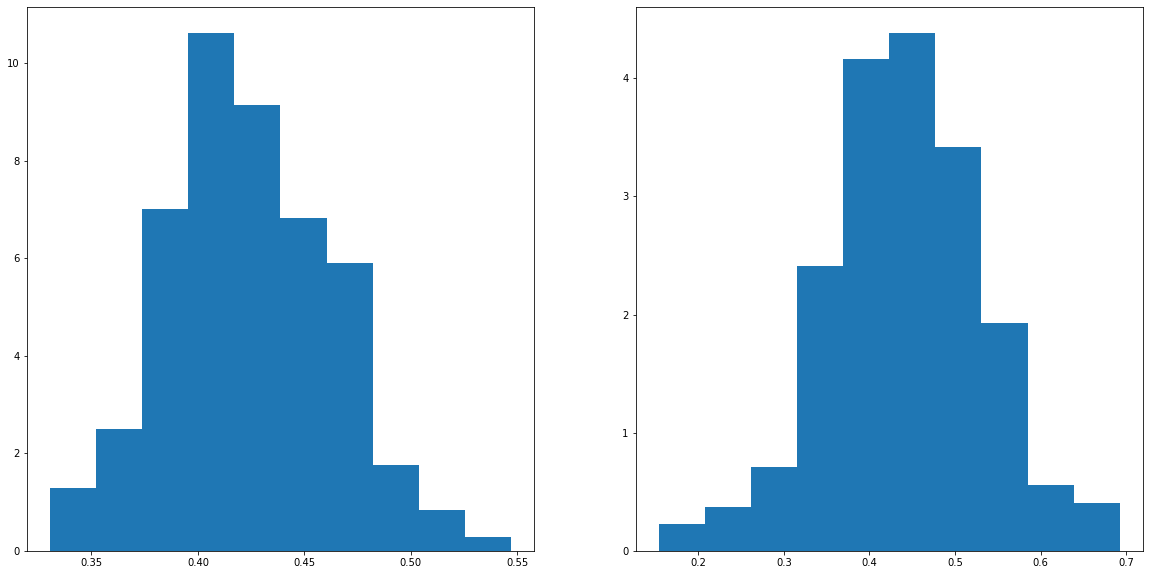

In [50]:
fig,ax=plt.subplots(1,2,figsize=(20,10))
ax[0].hist(train_scores, bins=10,density=True);
# ax[0].set_ylim(0,10);
# ax[0].set_xlim(0,1);
ax[1].hist(test_scores, bins=10, density=True);
# ax[1].set_ylim(0,10);
# ax[1].set_xlim(0,1);


In [51]:
%%time
# 1. Basic Random Forest
rf = RandomForestClassifier(
    n_estimators=200,      # number of trees
    max_depth=10,          # max depth of each tree (prevents overfitting)
    min_samples_split=10,   # minimum samples to split a node
    min_samples_leaf=1,    # minimum samples in leaf
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

# Fit model
rf.fit(X[train_indices], y[train_indices])

# Evaluate
train_acc = rf.score(X[train_indices], y[train_indices])
test_acc = rf.score(X[test_indices], y[test_indices])
num_lab=np.shape(y[test_indices])
num_permutations=1000
null_scores=[]
for j in range(num_permutations):
    y_null=np.random.choice(list(rf.classes_), size=num_lab)
    null_acc = rf.score(X[test_indices], y_null)
    null_scores.append(null_acc)
null_acc_final=np.mean(null_scores)

print(f"Random Forest Performance:")
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Null accuracy: {null_acc_final:.3f}")

# Detailed report
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X[test_indices])
print("\nTest Set Classification Report:")
print(classification_report(y[test_indices], y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y[test_indices], y_pred))

Random Forest Performance:
Train accuracy: 0.997
Test accuracy: 0.769
Null accuracy: 0.335

Test Set Classification Report:
              precision    recall  f1-score   support

         dec       1.00      0.92      0.96        13
        flat       0.62      0.77      0.69        13
         inc       0.73      0.62      0.67        13

    accuracy                           0.77        39
   macro avg       0.78      0.77      0.77        39
weighted avg       0.78      0.77      0.77        39


Confusion Matrix:
[[12  1  0]
 [ 0 10  3]
 [ 0  5  8]]
CPU times: user 29.3 s, sys: 3.13 s, total: 32.4 s
Wall time: 1min 46s


Top 20 Most Important Clusters:
     cluster  importance  single_test_acc
138      138    0.014727         0.435897
48        48    0.013514         0.589744
57        57    0.012049         0.435897
132      132    0.011290         0.538462
63        63    0.010906         0.538462
208      208    0.009642         0.564103
1          1    0.008596         0.512821
13        13    0.008592         0.666667
146      146    0.008502         0.564103
224      224    0.007769         0.435897
105      105    0.007735         0.512821
437      437    0.007628         0.435897
196      196    0.007228         0.564103
427      427    0.007130         0.435897
280      280    0.007001         0.512821
497      497    0.006987         0.538462
104      104    0.006936         0.564103
170      170    0.006861         0.538462
317      317    0.006551         0.564103
9          9    0.006352         0.435897


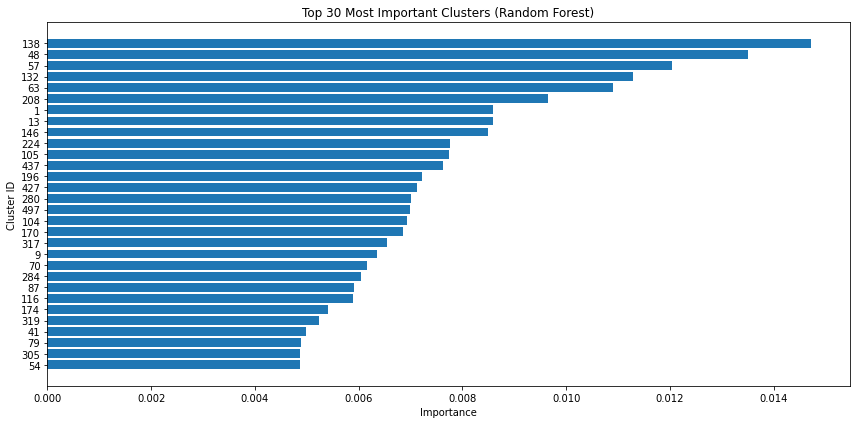

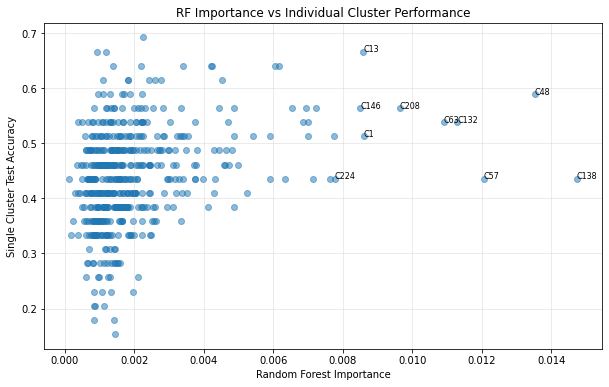

In [52]:
importances = rf.feature_importances_

# Create dataframe with cluster importance
importance_df = pd.DataFrame({
    'cluster': range(500),
    'importance': importances,
    'single_test_acc': test_scores  # from your earlier analysis
})

# Sort by importance
importance_df = importance_df.sort_values('importance', ascending=False)

print("Top 20 Most Important Clusters:")
print(importance_df.head(20))

# Plot feature importances
plt.figure(figsize=(12, 6))
top_30 = importance_df.head(30)
plt.barh(range(30), top_30['importance'].values)
plt.yticks(range(30), top_30['cluster'].values)
plt.xlabel('Importance')
plt.ylabel('Cluster ID')
plt.title('Top 30 Most Important Clusters (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Compare: RF importance vs single-cluster accuracy
plt.figure(figsize=(10, 6))
plt.scatter(importance_df['importance'], 
            importance_df['single_test_acc'], 
            alpha=0.5)
plt.xlabel('Random Forest Importance')
plt.ylabel('Single Cluster Test Accuracy')
plt.title('RF Importance vs Individual Cluster Performance')
plt.grid(True, alpha=0.3)

# Annotate top clusters
top_10 = importance_df.head(10)
for _, row in top_10.iterrows():
    plt.annotate(f"C{int(row['cluster'])}", 
                xy=(row['importance'], row['single_test_acc']),
                fontsize=8)

In [53]:
# # Find best parameters using cross-validation
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# grid_search = GridSearchCV(
#     rf, 
#     param_grid, 
#     cv=5,                    # 5-fold cross-validation
#     scoring='accuracy',
#     verbose=1,
#     n_jobs=-1
# )

# # Fit on training data
# grid_search.fit(X[train_indices], y[train_indices])

# print(f"Best parameters: {grid_search.best_params_}")
# print(f"Best CV score: {grid_search.best_score_:.3f}")

# # Use best model
# best_rf = grid_search.best_estimator_

# train_acc = best_rf.score(X[train_indices], y[train_indices])
# test_acc = best_rf.score(X[test_indices], y[test_indices])

# print(f"\nOptimized Random Forest:")
# print(f"Train accuracy: {train_acc:.3f}")
# print(f"Test accuracy: {test_acc:.3f}")

# # Get importance from best model
# importances = best_rf.feature_importances_

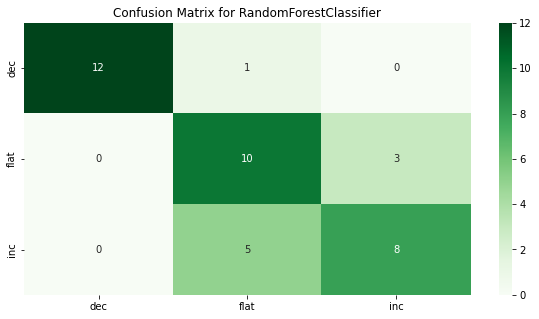

In [54]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(confusion_matrix(y[test_indices], y_pred), ax=ax, cmap='Greens', annot=True)
ax.xaxis.set_ticklabels(rf.classes_)
ax.yaxis.set_ticklabels(rf.classes_)
_ = ax.set_title(
    f"Confusion Matrix for {rf.__class__.__name__}"
)



In [55]:
ovr_rf = OneVsRestClassifier(rf)

ovr_rf.fit(X[train_indices], y[train_indices])

OneVsRestClassifier(estimator=RandomForestClassifier(max_depth=10,
                                                     min_samples_split=10,
                                                     n_estimators=200,
                                                     n_jobs=-1,
                                                     random_state=42))

In [56]:
class_names = list(rf.classes_)
class_importances = {}

for idx, (class_name, estimator) in enumerate(zip(class_names, ovr_rf.estimators_)):
    importances = estimator.feature_importances_
    class_importances[class_name] = importances
    
    # Top 10 for this class
    top_10_idx = np.argsort(importances)[-5:][::-1]
    print(f"\nTop 5 clusters for '{class_name}':")
    for rank, cluster in enumerate(top_10_idx, 1):
        print(f"  {rank}. Cluster {cluster}: {importances[cluster]:.4f}")

# Create DataFrame
importance_df_class = pd.DataFrame(class_importances)
importance_df_class['cluster'] = range(500)


Top 5 clusters for 'dec':
  1. Cluster 138: 0.0223
  2. Cluster 48: 0.0204
  3. Cluster 63: 0.0202
  4. Cluster 132: 0.0177
  5. Cluster 57: 0.0167

Top 5 clusters for 'flat':
  1. Cluster 138: 0.0095
  2. Cluster 427: 0.0093
  3. Cluster 369: 0.0083
  4. Cluster 133: 0.0080
  5. Cluster 9: 0.0078

Top 5 clusters for 'inc':
  1. Cluster 497: 0.0188
  2. Cluster 284: 0.0110
  3. Cluster 13: 0.0087
  4. Cluster 414: 0.0079
  5. Cluster 317: 0.0074


In [57]:
b='flat'
num=20
np.count_nonzero(np.isin(importance_df.head(20),list(importance_df_class.sort_values(by=b, ascending=False).head(num)['cluster'])))

7

In [58]:
# # Use ALL 500 clusters together
# X_train_all = X[train_indices]
# X_test_all = X[test_indices]
# y_train = y[train_indices]
# y_test = y[test_indices]

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_all)
# X_test_scaled = scaler.transform(X_test_all)

# model = LogisticRegression(max_iter=1000, C=1.0)
# model.fit(X_train_scaled, y_train)

# train_acc_all = model.score(X_train_scaled, y_train)
# test_acc_all = model.score(X_test_scaled, y_test)

# print(f"ALL 500 CLUSTERS:")
# print(f"Train accuracy: {train_acc_all:.3f}")
# print(f"Test accuracy: {test_acc_all:.3f}")

# # Detailed breakdown
# from sklearn.metrics import classification_report, confusion_matrix

# print("\nTRAIN SET CLASSIFICATION REPORT:")
# print(classification_report(y_train, model.predict(X_train_scaled)))

# print("\nTEST SET CLASSIFICATION REPORT:")
# print(classification_report(y_test, model.predict(X_test_scaled)))

# print("\nTEST SET CONFUSION MATRIX:")
# print(confusion_matrix(y_test, model.predict(X_test_scaled)))

In [59]:
# # 1. Best single cluster
# best_single_idx = np.argmax(test_scores)
# print(f"Best single cluster #{best_single_idx}:")
# print(f"  Train: {train_scores[best_single_idx]:.3f}")
# print(f"  Test: {test_scores[best_single_idx]:.3f}")

# # 2. Top 10 clusters
# top_10_idx = np.argsort(test_scores)[-10:]
# X_top10 = X[:, top_10_idx]
# X_train_top10 = X_top10[train_indices]
# X_test_top10 = X_top10[test_indices]

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_top10)
# X_test_scaled = scaler.transform(X_test_top10)

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train_scaled, y_train)

# print(f"\nTop 10 clusters:")
# print(f"  Train: {model.score(X_train_scaled, y_train):.3f}")
# print(f"  Test: {model.score(X_test_scaled, y_test):.3f}")

# # 3. Top 50 clusters
# top_50_idx = np.argsort(test_scores)[-50:]
# X_top50 = X[:, top_50_idx]
# X_train_top50 = X_top50[train_indices]
# X_test_top50 = X_top50[test_indices]

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_top50)
# X_test_scaled = scaler.transform(X_test_top50)

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train_scaled, y_train)

# print(f"\nTop 50 clusters:")
# print(f"  Train: {model.score(X_train_scaled, y_train):.3f}")
# print(f"  Test: {model.score(X_test_scaled, y_test):.3f}")

# # 4. All 500 clusters (from above)
# print(f"\nAll 500 clusters:")
# print(f"  Train: {train_acc_all:.3f}")
# print(f"  Test: {test_acc_all:.3f}")

In [60]:
# # Train on all clusters and see which are most important
# X_train_all = X[train_indices]
# X_test_all = X[test_indices]

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_all)
# X_test_scaled = scaler.transform(X_test_all)

# model = LogisticRegression(max_iter=1000, C=1.0)
# model.fit(X_train_scaled, y_train)

# # Get feature importance (coefficient magnitude)
# coef_importance = np.abs(model.coef_).mean(axis=0)  # Average across 3 classes

# # Top clusters by model weights
# top_clusters_by_coef = np.argsort(coef_importance)[-20:][::-1]

# print("\nTop 20 clusters by logistic regression coefficients:")
# for i, cluster in enumerate(top_clusters_by_coef):
#     print(f"{i+1}. Cluster {cluster}: "
#           f"Coef={coef_importance[cluster]:.4f}, "
#           f"Test Acc={test_scores[cluster]:.3f}")

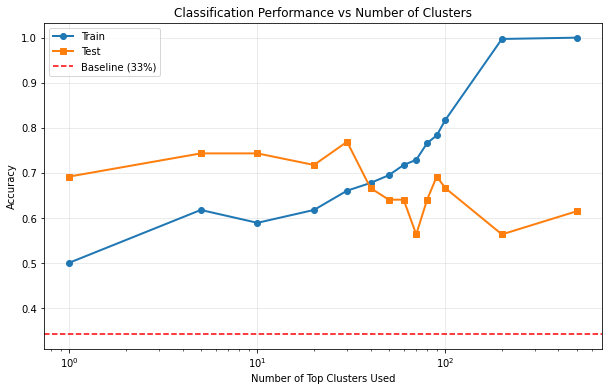


Performance summary:
  1 clusters: Train=0.501, Test=0.692
  5 clusters: Train=0.618, Test=0.744
 10 clusters: Train=0.590, Test=0.744
 20 clusters: Train=0.618, Test=0.718
 30 clusters: Train=0.661, Test=0.769
 40 clusters: Train=0.678, Test=0.667
 50 clusters: Train=0.695, Test=0.641
 60 clusters: Train=0.718, Test=0.641
 70 clusters: Train=0.729, Test=0.564
 80 clusters: Train=0.766, Test=0.641
 90 clusters: Train=0.783, Test=0.692
100 clusters: Train=0.818, Test=0.667
200 clusters: Train=0.997, Test=0.564
500 clusters: Train=1.000, Test=0.615


In [61]:
# Plot performance vs number of top clusters used
n_clusters_to_test = [1, 5, 10, 20, 30,40, 50,60,70,80,90,100, 200, 500]
train_accs = []
test_accs = []

for n in n_clusters_to_test:
    if n == 1:
        # Use best single cluster
        idx = [np.argmax(test_scores)]
    else:
        idx = np.argsort(test_scores)[-n:]
    
    X_subset = X[:, idx]
    X_train_sub = X_subset[train_indices]
    X_test_sub = X_subset[test_indices]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sub)
    X_test_scaled = scaler.transform(X_test_sub)
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    
    train_accs.append(model.score(X_train_scaled, y_train))
    test_accs.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_clusters_to_test, train_accs, 'o-', label='Train', linewidth=2)
plt.plot(n_clusters_to_test, test_accs, 's-', label='Test', linewidth=2)
plt.axhline(0.343, color='red', linestyle='--', label='Baseline (33%)')
plt.xlabel('Number of Top Clusters Used')
plt.ylabel('Accuracy')
plt.title('Classification Performance vs Number of Clusters')
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nPerformance summary:")
for n, train, test in zip(n_clusters_to_test, train_accs, test_accs):
    print(f"{n:3d} clusters: Train={train:.3f}, Test={test:.3f}")

In [27]:
# %%time
# #preload cluster #s
# large_events={}
# for k in sig_diff_rois:
#     large_events[k]={'label':[],'vals':[]}
# for k in sig_diff_rois:
#     for fly in fly_clust:
# #         print(f'fly is {fly}')
#         for i,event in enumerate(event_labels[str(fly)]['idx']):
#             clust_group=[]
#             label_group=[]
#             for cluster in sig_diff_rois:
#                 clust_group.append(fly_clust[fly][cluster][event][-2:])
#                 label_group.append(event_labels[str(fly)]['label'][i])
#     #         print(np.shape(clust_group))
#             clust_val=np.sum(clust_group,axis=0)
#             if np.unique(label_group).shape[0]==1:
#                 label_val=np.unique(label_group)[0]
#             else:
#                 print('theres a problem bitch')
#                 break
#             large_events[k]['label'].append(label_val)
#             large_events[k]['vals'].append(clust_val)
#     large_events[k]['vals']=np.asarray(large_events[k]['vals'])
#     large_events[k]['label']=np.asarray(large_events[k]['label'])

In [28]:
# np.shape(large_events[0]['vals'])

In [29]:
clf=sklearn.linear_model.LogisticRegression(penalty='none', random_state=0,multi_class='ovr')

In [30]:
# fit_events={}
# test_events={}
# for k in large_events:
#     fit_events[k]={'label':[],'vals':[]}
#     test_events[k]={'label':[],'vals':[]}
#     num_trial=large_events[k]['label'].shape[0]
#     trial_90=int(num_trial*0.9)
# #     print(trial_90)
#     arr=np.random.choice(np.arange(num_trial),trial_90,replace=False)
#     arr = np.sort(np.asarray(arr).astype(int))
#     to_fit_X=large_events[k]['vals'][arr] #.reshape(-1, 1)
#     to_fit_y=large_events[k]['label'][arr]
#     clf.fit(to_fit_X, to_fit_y)
#     fit_events[k]['vals']=np.asarray(to_fit_X)
#     fit_events[k]['label']=np.asarray(to_fit_y)
#     out=~np.isin(np.arange(num_trial),arr)
#     test_events[k]['vals']=np.asarray(large_events[k]['vals'][out])
#     test_events[k]['label']=np.asarray(large_events[k]['label'][out])

In [31]:
fit_events={}
test_events={}
for cluster in range_r:
    test_events[cluster]={}
    fit_events[cluster]={}
for clust in best_events:
    data_labels=np.asarray(best_events[clust]['label'])
    labels = np.where((data_labels == 'inc') | (data_labels == 'flat'))
    data_labels=np.asarray(best_events[clust]['label'])[labels]
    data_vals=np.asarray(best_events[clust]['vals'])[labels]
    num_trial=np.shape(data_labels)[0]
    trial_90=np.floor(num_trial*0.9).astype(int)
    arr=np.random.choice(np.arange(num_trial),trial_90,replace=False)
    arr = np.sort(np.asarray(arr).astype(int))
#     print(np.shape(arr))
    to_fit_X=data_vals[arr]
    to_fit_y=data_labels[arr]
    clf.fit(to_fit_X, to_fit_y)
    fit_events[clust]['vals']=np.asarray(to_fit_X)
    fit_events[clust]['label']=np.asarray(to_fit_y)
    out=~np.isin(np.arange(num_trial),arr)
    test_events[clust]['vals']=np.asarray(data_vals[out])
    test_events[clust]['label']=np.asarray(data_labels[out])

In [32]:
np.shape(test_events[cluster]['vals'])

(25, 1)

In [33]:
to_plot_dec=[]
to_plot_inc=[]
to_plot_flat=[]
events=best_events
# test_clust=np.arange(10,15)
for clust in events:
    data=np.asarray(events[clust]['vals'])
    labels=np.asarray(events[clust]['label'])
    dec=np.where((labels == 'dec'))[0]
    inc=np.where((labels == 'inc'))[0]
    flat=np.where((labels == 'flat'))[0]
    to_plot_dec.append(data[dec])
    to_plot_inc.append(data[inc])
    to_plot_flat.append(data[flat])
    
to_plot_dec=np.vstack(to_plot_dec)
to_plot_inc=np.vstack(to_plot_inc)
to_plot_flat=np.vstack(to_plot_flat)
print(np.shape(to_plot_inc))

(63000, 1)


In [34]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [35]:
all_data = events[clust]['vals']
vmin,vmax=np.nanmin(all_data),np.nanmax(all_data)
vmin,vmax

(-0.19451982, 0.30183414)

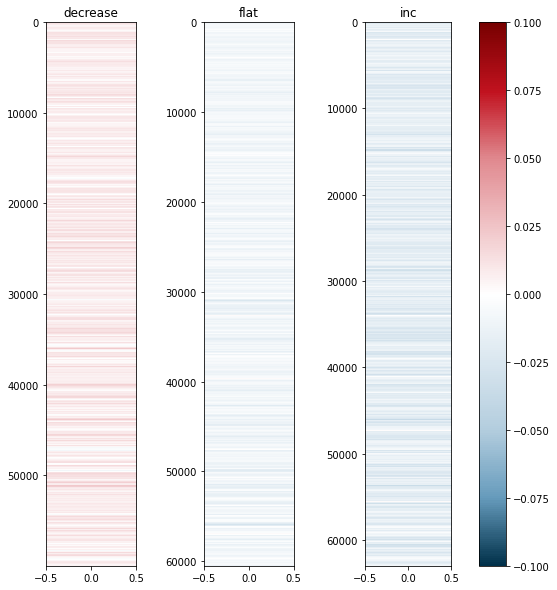

In [36]:
vmin=-0.1
vmax=0.1
ax_ap=0.0001
fig,ax=plt.subplots(1,3,figsize=(10,10))
im1=ax[0].imshow(np.asarray(to_plot_dec), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[0].set_title('decrease')
ax[0].set_aspect(ax_ap)
ax[1].imshow(np.asarray(to_plot_flat), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[1].set_aspect(ax_ap)
ax[1].set_title('flat')
ax[2].imshow(np.asarray(to_plot_inc), cmap=cmap_personal,vmax=vmax,vmin=-vmax)
ax[2].set_aspect(ax_ap)
ax[2].set_title('inc')
fig.colorbar(im1,ax=[ax[0],ax[1],ax[2]])
# plt.tight_layout

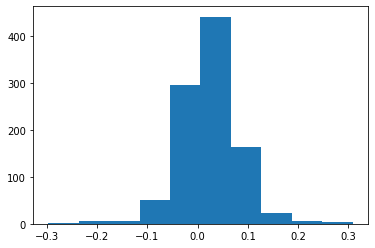

In [37]:
plt.hist(np.asarray(to_plot_dec[:1000]-to_plot_inc[:1000]));

In [38]:
fit_predictions={}
fit_scores=[]
for clust in test_events:
    fit_predictions[clust]={}
    X=fit_events[clust]['vals']
    y=fit_events[clust]['label']
    fit_predictions[clust]['prediction']=clf.predict(X)
    fit_predictions[clust]['percent']=clf.predict_proba(X)
    predictions[clust]['params']=clf.get_params()
    fit_scores.append(clf.score(X,y))
fit_scores=np.asarray(fit_scores)

NameError: name 'predictions' is not defined

In [ ]:
predictions={}
scores=[]
for clust in test_events:
    predictions[clust]={}
    X=test_events[clust]['vals']
    y=test_events[clust]['label']
    predictions[clust]['prediction']=clf.predict(X)
    predictions[clust]['percent']=clf.predict_proba(X)
    predictions[clust]['params']=clf.get_params()
    scores.append(clf.score(X,y))
scores=np.asarray(scores)

In [ ]:
scores.shape

In [ ]:
np.max(scores)

In [ ]:
np.max(fit_scores)

In [ ]:
c=0
predictions[c]['prediction']

In [ ]:
# for g in predictions:
#     print(g, np.count_nonzero(predictions[g]['prediction']!='dec'))

In [ ]:
test_events[c]['label']

In [ ]:
predictions[c]['params']

In [ ]:
class_order=clf.classes_
class_order

In [ ]:
predictions[c]['percent']

In [ ]:
max_min=[]
for clus in test_events:
    max_val=np.max(list(test_events[clus]['vals']))
    min_val=np.min(list(test_events[clus]['vals']))
    max_min.append([max_val,min_val])
max_overall=np.max(max_min)
min_overall=np.min(max_min)

In [ ]:
print(max_overall,min_overall)

In [ ]:
%%time
num_permutations=1000
total_null_scores=[]
for x in range(num_permutations):
    null_scores=[]
    for clust in test_events:
        X=test_events[clust]['vals']
        num_lab=test_events[cluster]['label'].shape[0]
        y=np.random.choice(class_order, size=num_lab)
        null_scores.append(clf.score(X,y))
    total_null_scores.append(null_scores)
total_null_scores=np.asarray(total_null_scores)

In [ ]:
avg_null_score=np.mean(total_null_scores,axis=0)
total_null_scores.shape

In [ ]:
rois=[0,   7,  14,  27,  29,  39,  44,  51,  52,  53,  61,  63,  81,
        85,  92,  96, 101, 103, 112, 117, 118, 125, 128, 129, 131, 137,
       139, 142, 143, 149, 151, 154, 155, 157, 158, 163, 169, 172, 177,
       178, 181, 189, 190, 201, 203, 206, 208, 215, 216, 218, 225, 227,
       228, 235, 238, 241, 250, 252, 255, 256, 257, 261, 263, 264, 267,
       268, 275, 277, 280, 287, 288, 290, 291, 292, 295, 298, 303, 304,
       305, 311, 312, 315, 317, 320, 321, 323, 324, 329, 333, 334, 337,
       341, 343, 352, 353, 358, 360, 361, 365, 370, 380, 381, 383, 394,
       395, 402, 406, 408, 417, 421, 425, 428, 436, 439, 442, 445, 446,
       448, 452, 455, 461, 462, 465, 474, 475, 478, 480, 481, 482]

In [ ]:
giant_cluster=[]
for roi in rois:
    tester=test_events[roi]['vals']
    giant_cluster.append(tester)
giant_cluster=np.sum(giant_cluster,axis=0)
y=test_events[roi]['label']
giant_score_in=clf.score(giant_cluster,y)
giant_predict_percent_in=clf.predict_proba(giant_cluster)

In [ ]:
not_in=~np.isin(np.arange(500),rois)
giant_cluster=[]
for roi in not_in:
    tester=test_events[roi]['vals']
    giant_cluster.append(tester)
giant_cluster=np.sum(giant_cluster,axis=0)
y=test_events[roi]['label']
giant_score_notin=clf.score(giant_cluster,y)
giant_predict_percent_notin=clf.predict_proba(giant_cluster)

In [ ]:
other=[  0,  92, 117, 129, 158, 178, 181, 189, 225, 228, 235, 255, 256,
       263, 268, 287, 288, 290, 291, 292, 352, 353, 361, 381, 406, 425,
       452, 461, 462, 480, 482]

In [ ]:
giant_cluster=[]
for roi in other:
    tester=test_events[roi]['vals']
    giant_cluster.append(tester)
giant_cluster=np.sum(giant_cluster,axis=0)
y=test_events[roi]['label']
giant_score_in=clf.score(giant_cluster,y)
giant_predict_percent_in=clf.predict_proba(giant_cluster)

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(20,10))
ax[0].hist(fit_scores, bins=10,density=True);
# ax[0].hist(scores, bins=10, density=True);
# ax[0].hist(giant_score_in, bins=10, density=True);
ax[0].set_ylim(0,10);
ax[0].set_xlim(0,1);
# ax[0].hist(fit_scores, bins=10,density=True);
ax[1].hist(scores, bins=10, density=True);
# ax[0].hist(giant_score_in, bins=10, density=True);
ax[1].set_ylim(0,10);
ax[1].set_xlim(0,1);
# ax[2].hist(total_null_scores, bins=10,density=True);
# ax[2].set_ylim(0,10);
# ax[2].set_xlim(0,1);

# ax.hist(giant_score_notin, bins=10, density=True);


In [ ]:
print(np.max(scores),np.min(scores))
print(np.max(fit_scores),np.min(fit_scores))
print(np.max(null_scores),np.min(null_scores))

In [ ]:
full_res_scores=[]
n_clusters=500
cluster_brain=scores
brain=cluster_brain
cluster_labels=giant_total_labels
n_clusters = brain.shape[0]
brain_dims=[314,146,91]

colored_by_betas = np.zeros((brain_dims[0]*brain_dims[1]*brain_dims[2]))
colored_by_betas = brain[cluster_labels]  # Shape: (n_tp, n_voxels)
colored_by_betas = colored_by_betas.reshape(brain_dims[0], brain_dims[1], brain_dims[2])
#     for cluster_num in range(n_clusters):
#         cluster_mask = cluster_labels==cluster_num
# #         print(np.shape(cluster_mask))
#         colored_by_betas[:,cluster_mask] = brain[:,cluster_num,np.newaxis]
colored_by_betas = colored_by_betas.reshape(brain_dims[0],brain_dims[1],brain_dims[2])
full_res_scores=colored_by_betas
full_res_scores=np.asarray(full_res_scores)

In [ ]:
full_res_scores.shape

In [ ]:
roi_atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [ ]:
def explode_plot(brain,vmax,explosion_rois,roi_masks,roi_contours,tp=None,cmap='seismic'):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    if tp==None:
        data_to_plot = brain[:,:,::-1]
    else:
        data_to_plot = brain[tp][:,:,::-1]
    vmax =vmax #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap=cmap, diverging=False)#'hot')
    return explosion_map

In [ ]:
ax_as=1.5
vmax=np.max(full_res_scores)
fig,axs=plt.subplots(figsize=(10,10))
temp=explode_plot(full_res_scores,vmax,explosion_rois,roi_masks,roi_contours,cmap='hot_r')
brain=axs.imshow(temp[170:,:]) #this was made with cmap=hot
axs.axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs.set_aspect(ax_as)


In [ ]:
top_predictors=np.where(scores>=0.65)
least_predictors=np.where(scores<0.3)

In [ ]:
top_predictors

In [98]:
fixed = brainsss.load_fda_meanbrain()

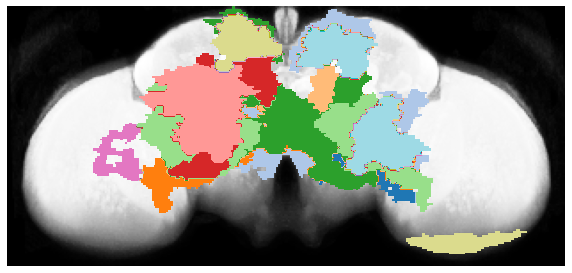

In [153]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,importance_df.head(20)),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='tab20')
ax.axis('off');

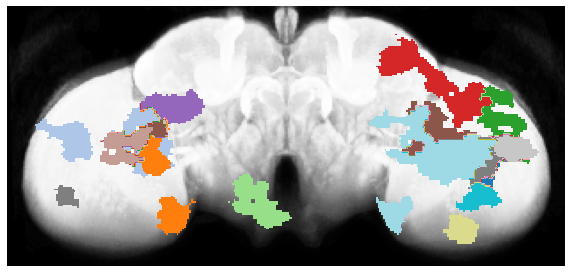

In [154]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,importance_df.tail(20)),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='tab20')
ax.axis('off');

In [ ]:
ax_as=1.5
vmax=0.8
fig,axs=plt.subplots(1,2,figsize=(20,10))
masked_nonan=np.where(np.isin(giant_labels_anat,top_predictors),full_res_scores, np.nan)
masked_nonan=np.nan_to_num(masked_nonan)
temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,cmap='hot_r')
brain=axs[0].imshow(temp[170:,:]) #this was made with cmap=hot
axs[0].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs[0].set_aspect(ax_as)
masked_nonan=np.where(np.isin(giant_labels_anat,least_predictors),full_res_scores, np.nan)
masked_nonan=np.nan_to_num(masked_nonan)
temp=explode_plot(masked_nonan,vmax,explosion_rois,roi_masks,roi_contours,cmap='hot_r')
brain=axs[1].imshow(temp[170:,:]) #this was made with cmap=hot
axs[1].axis('off')
#     axs[i].set_title(f'{tp}',fontsize=50)
axs[1].set_aspect(ax_as)

In [ ]:
avg_prob_by_behave=[]
for c in top_predictors:
    avg_prob=np.max(predictions[c]['percent'],axis=0)
    avg_prob_by_behave.append(avg_prob)
avg_prob_by_behave=np.asarray(avg_prob_by_behave)
print(avg_prob_by_behave.shape)

In [ ]:
df = pd.DataFrame(avg_prob_by_behave, columns=class_order)
df.index.name = 'Cluster'
df_long = df.reset_index().melt(id_vars='Cluster', 
                                  var_name='Behavior', 
                                  value_name='Value')
# df_long.rename(columns={'index': 'Cluster'}, inplace=True)

In [ ]:
df_long.shape

In [ ]:
behavior_colors={
    'inc': '#9400D3',
    'dec': '#727272',
    'flat': '#000000'
}

In [ ]:
fig,ax=plt.subplots(figsize=(30,10))
sns.barplot(data=df_long, x='Cluster', y='Value', hue='Behavior', palette=behavior_colors)
ax.set_xticklabels(top_predictors);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right');
ax.tick_params(axis='x', labelsize=20);
ax.tick_params(axis='y', labelsize=20);

In [ ]:
avg_prob_by_behave=[]
for c in range(500):
    avg_prob=np.max(predictions[c]['percent'],axis=0)
    avg_prob_by_behave.append(avg_prob)
avg_prob_by_behave=np.asarray(avg_prob_by_behave)
print(avg_prob_by_behave.shape)

In [ ]:
df = pd.DataFrame(avg_prob_by_behave, columns=class_order)
df.index.name = 'Cluster'
df_long = df.reset_index().melt(id_vars='Cluster', 
                                  var_name='Behavior', 
                                  value_name='Value')
# df_long.rename(columns={'index': 'Cluster'}, inplace=True)

In [ ]:
array = np.arange(0, 500, 50) 
array.shape

In [ ]:
fig,ax=plt.subplots(10,1,figsize=(50,40))
bin_size=np.arange(0, 500, 50) 
for x in range(np.shape(bin_size)[0]):
    start=bin_size[x]
    if start>=bin_size[-1]:
        end=499
    else:
        end=bin_size[x+1]
#     print(start,end)
    df_subset = df_long[(df_long['Cluster'] > start) & (df_long['Cluster'] <= end)]
    sns.barplot(data=df_subset, x='Cluster', y='Value', hue='Behavior', palette=behavior_colors, ax=ax[x])
    ax[x].get_legend().remove()
    ax[x].tick_params(axis='x', labelsize=20);
#     ax[x].set_xticklabels(np.arange(50));

In [ ]:
big_pred=[499,435,364,354,321,291,256,233,181,131,59] #465,479,290,

In [ ]:
giant_labels_anat=giant_total_labels.reshape(314,146,91)
labels_anat_sub_total=np.where(np.isin(giant_labels_anat,big_pred),giant_labels_anat,np.nan)
# labels_anat_sub_total=np.where(np.isin(giant_labels_anat,top_indices[0]),giant_labels_anat,np.nan)   
fig,ax=plt.subplots(figsize=(10,10))
ax.imshow(np.nanmax(fixed.numpy(),axis=-1).T,cmap='Greys_r')
ax.imshow(np.nanmax(labels_anat_sub_total,axis=-1).T,cmap='spring')
ax.axis('off');